## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



### Tutorial of Machine Learning Algorithms
 * Basic exploratory data analysis
 * Classic ML algorithms for regression and classification problems
   1. Linear regression
   2. Decision tree
   3. Support vector machine
   4. Logistic regression
* More advanced ML algorithms
   5. Bayesian regression
   6. Fuzzy decision tree
* Problems:
   1. Regression: from sklearn.datasets import fetch_california_housing
   2. Classification: from sklearn.datasets import load_breast_cancer
* Bayesian optimization for hyperparameter

In [1]:
%load_ext autoreload
%autoreload 2

##### 1 Decision Tree and Fuzzy Decision Tree for Breast Cancer Dataset

Error details: __init__() got an unexpected keyword argument 'random_state'
Trying with default parameters.


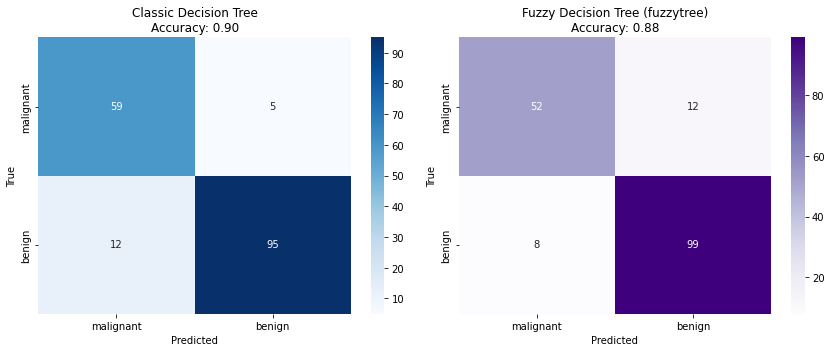

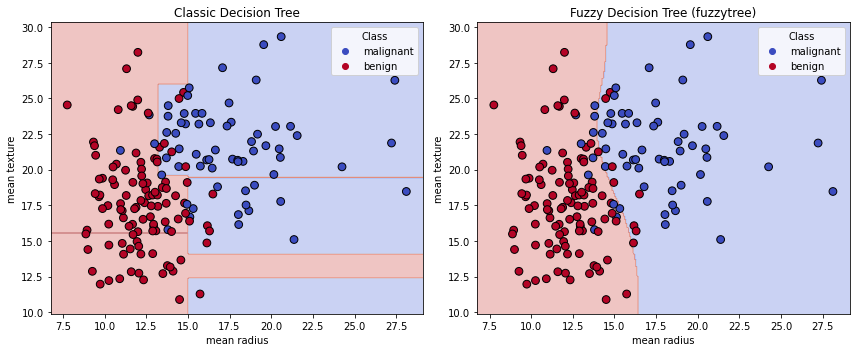

In [2]:
# Classic and Fuzzy Decision Tree on Breast Cancer Dataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Try importing fuzzytree for fuzzy decision tree
try:
    from fuzzytree import FuzzyDecisionTreeClassifier
    fuzzytree_available = True
except ImportError as e:
    print("WARNING: Could not import fuzzytree.")
    print("Error details:", e)
    print("Fuzzy Decision Tree will be skipped. To fix, try installing fuzzytree (pip install fuzzytree).")
    fuzzytree_available = False

# 1. Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# For visualization, select two features for 2D plotting
feat_idx = [0, 1]  # mean radius, mean perimeter (for example)
X_vis = X[:, feat_idx]

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_vis, y, test_size=0.3, random_state=42, stratify=y)

# 3. Classic Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

# 4. Fuzzy Decision Tree using fuzzytree (if available)
if fuzzytree_available:
    # NOTE: The FuzzyDecisionTreeClassifier in fuzzytree may not accept 'n_labels' as a parameter.
    # We'll only pass parameters that are supported by the installed version.
    # If you want to tune the fuzziness, check the fuzzytree docs for supported arguments.
    fuzzy_params = {
        # "n_labels": 7,         # number of fuzzy sets per feature (higher = smoother)  # Not used due to error
        "fuzziness": 2.0,      # fuzziness parameter (higher = more overlap)
        "max_depth": 4,        # match classic tree for fair comparison
        "random_state": 42
    }
    # Only pass supported parameters
    try:
        dt_fuzzy = FuzzyDecisionTreeClassifier(
            fuzziness=fuzzy_params["fuzziness"],
            max_depth=fuzzy_params["max_depth"],
            random_state=fuzzy_params["random_state"]
        )
    except TypeError as e:
        print("WARNING: Could not initialize FuzzyDecisionTreeClassifier with the given parameters.")
        print("Error details:", e)
        print("Trying with default parameters.")
        dt_fuzzy = FuzzyDecisionTreeClassifier()
    dt_fuzzy.fit(X_train, y_train)
    y_pred_fuzzy = dt_fuzzy.predict(X_test)
    acc_fuzzy = accuracy_score(y_test, y_pred_fuzzy)
    cm_fuzzy = confusion_matrix(y_test, y_pred_fuzzy)
else:
    dt_fuzzy = None
    acc_fuzzy = None
    cm_fuzzy = None

# 5. Plot accuracy matrix (confusion matrices)
fig, axs = plt.subplots(1, 2 if fuzzytree_available else 1, figsize=(12, 5) if fuzzytree_available else (6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axs[0] if fuzzytree_available else axs)
if fuzzytree_available:
    axs[0].set_title(f"Classic Decision Tree\nAccuracy: {acc_dt:.2f}")
    axs[0].set_xlabel("Predicted")
    axs[0].set_ylabel("True")
    axs[0].set_xticklabels(target_names)
    axs[0].set_yticklabels(target_names)

    sns.heatmap(cm_fuzzy, annot=True, fmt='d', cmap='Purples', ax=axs[1])
    axs[1].set_title(f"Fuzzy Decision Tree (fuzzytree)\nAccuracy: {acc_fuzzy:.2f}")
    axs[1].set_xlabel("Predicted")
    axs[1].set_ylabel("True")
    axs[1].set_xticklabels(target_names)
    axs[1].set_yticklabels(target_names)
else:
    axs.set_title(f"Classic Decision Tree\nAccuracy: {acc_dt:.2f}")
    axs.set_xlabel("Predicted")
    axs.set_ylabel("True")
    axs.set_xticklabels(target_names)
    axs.set_yticklabels(target_names)

plt.tight_layout()
plt.show()

# 6. Plot decision boundaries
def plot_decision_boundary(clf, X, y, title, is_fuzzy=False, fuzzy_params=None, feat_idx=(0, 1)):
    n_features = X.shape[1]
    if any(idx >= n_features for idx in feat_idx):
        raise ValueError(f"feat_idx {feat_idx} is out of bounds for input with {n_features} features.")
    x_min, x_max = X[:, feat_idx[0]].min() - 1, X[:, feat_idx[0]].max() + 1
    y_min, y_max = X[:, feat_idx[1]].min() - 1, X[:, feat_idx[1]].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # If the classifier expects all features, expand grid to full feature space
    if X.shape[1] > 2:
        grid_full = np.zeros((grid.shape[0], X.shape[1]))
        grid_full[:, feat_idx[0]] = grid[:, 0]
        grid_full[:, feat_idx[1]] = grid[:, 1]
        for i in range(X.shape[1]):
            if i not in feat_idx:
                grid_full[:, i] = np.mean(X[:, i])
    else:
        grid_full = grid

    Z = None
    if is_fuzzy and fuzzytree_available:
        # FuzzyDecisionTreeClassifier expects the same input as classic tree
        Z = clf.predict(grid_full)
    elif clf is not None:
        Z = clf.predict(grid_full)
    if Z is not None:
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X[:, feat_idx[0]], X[:, feat_idx[1]], c=y, cmap=plt.cm.coolwarm, edgecolor='k', s=60)
    plt.xlabel(feature_names[feat_idx[0]])
    plt.ylabel(feature_names[feat_idx[1]])
    plt.title(title)
    handles, legend_labels = scatter.legend_elements()
    n_classes = len(target_names)
    handles = handles[:n_classes]
    legend_labels = [target_names[i] for i in range(n_classes)]
    plt.legend(handles=handles, labels=legend_labels, title="Class")
    plt.tight_layout()

def safe_feat_idx(X, feat_idx):
    n_features = X.shape[1]
    if not isinstance(feat_idx, (tuple, list)) or len(feat_idx) != 2:
        return (0, 1)
    if any(idx >= n_features for idx in feat_idx):
        return (0, 1)
    return feat_idx

if fuzzytree_available:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plot_decision_boundary(
        dt_clf, 
        X_test, 
        y_test, 
        "Classic Decision Tree", 
        feat_idx=safe_feat_idx(X_test, feat_idx)
    )
    plt.subplot(1, 2, 2)
    plot_decision_boundary(
        dt_fuzzy, 
        X_test, 
        y_test, 
        "Fuzzy Decision Tree (fuzzytree)", 
        is_fuzzy=True,
        fuzzy_params=fuzzy_params,
        feat_idx=safe_feat_idx(X_test, feat_idx)
    )
    plt.show()
else:
    plt.figure(figsize=(6, 5))
    plot_decision_boundary(
        dt_clf, 
        X_test, 
        y_test, 
        "Classic Decision Tree", 
        feat_idx=safe_feat_idx(X_test, feat_idx)
    )
    plt.show()
